In [15]:
import csv
from datetime import datetime
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

import trompy as tp

mpl.rcParams['savefig.transparent'] = True
mpl.rcParams['font.family'] = 'Arial'

SAVEFIGS = True
DISPLAY_DPI = 150
EXPORT_DPI = 600
np.random.seed(42)  # For reproducibility of jitter


In [16]:
# Assemble data

def get_FEDevents(filename, eventname):
    formats = ['%Y-%m-%d %H:%M:%S', '%m/%d/%Y %H:%M:%S']
    
    try:
        file = open(filename)
    except FileNotFoundError:
        print(f"File not found: {filename}")
        return []
    
    csvreader = csv.reader(file)
    next(csvreader)  # Skip header
    rows = []
    for row in csvreader:
        rows.append(row)

    # Check if rows are empty
    if len(rows) == 0:
        print(f"No data found in file: {filename}")
        return []

    # Determine which format should be used
    try:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[0])
        date_format = formats[0]
    except ValueError:
        tmp_date_time_obj = datetime.strptime(rows[0][0], formats[1])
        date_format = formats[1]

    timestamps = []
    for row in rows: 
        if row[7] == eventname:  # Check event column
            date_time_obj = datetime.strptime(row[0], date_format)
            timestamps.append(date_time_obj)

    if len(timestamps) == 0:
        print(f"No {eventname} events found in file: {filename}")
        return []

    t0 = rows[0][0]
    day = t0.split()[0] 
    lightson = day + " 07:00:00"
    refpoint = datetime.strptime(lightson, date_format)
    
    pellettimes = []
    for t in timestamps:
        Deltat = t - refpoint
        Deltatinseconds = Deltat.total_seconds()
        Deltatinhours = Deltatinseconds / 3600
        pellettimes.append(Deltatinhours)

    return pellettimes

def get_data_subset(dictionary, selectors, verbose=True):
    output_dictionary = dictionary.copy()
    for key, value in selectors.items():
        for mouse_id in dictionary.keys():
            try:
                if output_dictionary[mouse_id][key] != value:
                    output_dictionary.pop(mouse_id)
            except KeyError: 
                pass

    if verbose:
        print("{} items in output dictionary".format(len(output_dictionary.keys())))
    
    return output_dictionary

def get_data_fields(dictionary, fields, selectors):
    output_list = []
    reduced_dictionary = get_data_subset(dictionary, selectors)
    
    if len(reduced_dictionary.keys()) > 0:
        for field in fields:
            output_sublist = []
            try:
                for key in reduced_dictionary.keys():
                    output_sublist.append(reduced_dictionary[key][field])
            except KeyError:
                print("{} is not a key in selected dictionary".format(field))
                return
            output_list.append(output_sublist)
    else:
        print("No data in fields in selected dictionary")

    if len(output_list) == 1:
        output_list = output_list[0]
        
    return output_list
# Function to get meal, snack, and mega meal metrics, including mega_meal_frequency and mega_meal_size
def get_meal_and_snack_metrics(pellettimes, meal_threshold=1/60):
    if not pellettimes:
        return (0, 0, 0, 0, 0, 0, 0, 0, [[0]*24]*7, [[0]*24]*7, [[0]*24]*7, 0, 0, 0, 0)

    IPIs = np.diff(np.array(pellettimes))
    meals = []
    snacks = []
    mega_meals = []
    current_event = [pellettimes[0]]

    # Hourly tracking for each day
    hourly_meals_per_day = [[0]*24 for _ in range(7)]
    hourly_snacks_per_day = [[0]*24 for _ in range(7)]
    hourly_mega_meals_per_day = [[0]*24 for _ in range(7)]

    for i, ipi in enumerate(IPIs):
        if ipi <= meal_threshold:
            current_event.append(pellettimes[i + 1])
        else:
            if len(current_event) == 1:
                snacks.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:  # Make sure we are within the 7-day boundary
                    hourly_snacks_per_day[day_index][hour] += 1
            elif 2 <= len(current_event) <= 5:
                meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_meals_per_day[day_index][hour] += 1
            elif len(current_event) >= 6:
                mega_meals.append(current_event)
                day_index = int(current_event[0] // 24)
                hour = int(current_event[0]) % 24
                if day_index < 7:
                    hourly_mega_meals_per_day[day_index][hour] += 1
            current_event = [pellettimes[i + 1]]

    # Handle the last sequence
    if current_event:
        day_index = int(current_event[0] // 24)
        hour = int(current_event[0]) % 24
        if len(current_event) == 1:
            snacks.append(current_event)
            if day_index < 7:
                hourly_snacks_per_day[day_index][hour] += 1
        elif 2 <= len(current_event) <= 4:
            meals.append(current_event)
            if day_index < 7:
                hourly_meals_per_day[day_index][hour] += 1
        elif len(current_event) >= 5:
            mega_meals.append(current_event)
            if day_index < 7:
                hourly_mega_meals_per_day[day_index][hour] += 1

    nmeals = len(meals)
    nsnacks = len(snacks)
    n_mega_meals = len(mega_meals)  # Add the number of mega meals

    total_pellets = len(pellettimes)
    mealsize = sum(len(meal) for meal in meals) / nmeals if nmeals else 0
    snack_size = sum(len(snack) for snack in snacks) / nsnacks if nsnacks else 0
    total_observation_period = max(pellettimes) - min(pellettimes)
    meal_frequency = nmeals / total_observation_period if total_observation_period > 0 else 0
    snack_frequency = nsnacks / total_observation_period if total_observation_period > 0 else 0
    mega_meal_frequency = n_mega_meals / total_observation_period if total_observation_period > 0 else 0
    average_mega_meal_size = sum(len(meal) for meal in mega_meals) / n_mega_meals if n_mega_meals else 0

    return (mealsize, snack_size, nmeals, meal_frequency, nsnacks, snack_frequency, 
            mega_meal_frequency, average_mega_meal_size, hourly_meals_per_day, 
            hourly_snacks_per_day, hourly_mega_meals_per_day, meals, snacks, mega_meals, n_mega_meals)


# Function to get events (meals, snacks, mega meals) per day based on timestamps
def get_events_per_day(events, days=7):
    events_per_day = [0] * days  # Initialize with zeros for the duration of the phase
    for event_list in events:
        if len(event_list) > 0:
            event_day = int(event_list[0] // 24)
            if event_day < days:
                events_per_day[event_day] += 1
    return events_per_day

# Function to calculate pellets per day
def get_pellets_per_day(timestamps, days=7):
    pellets_per_day = [0] * days
    for day in range(days):
        pellets = [t for t in timestamps if (t > day * 24) and (t < (day + 1) * 24)]
        n_pellets = len(pellets)
        pellets_per_day[day] = n_pellets

    return pellets_per_day


# Function to calculate inter-pellet intervals (IPI)
def get_interpellet_intervals(pellettimes):
    IPIs = np.diff(pellettimes)
    return IPIs

# Function to calculate intermeal intervals (IMI)
def get_intermeal_interval(pellettimes, meal_threshold=1/60):
    IPIs = np.diff(pellettimes)
    IMIs = [x for x in IPIs if x > meal_threshold]
    average_IMI = np.mean(IMIs) if IMIs else 0  # Handle case with no IMIs
    return average_IMI

# Load the metafile and process the data
metafile = "..\\src\\FEDProtein_METAFILE.xls"
rows, header = tp.metafilereader(metafile, sheetname="METAFILE")

mice = {}
for row in rows:
    mouse_id = row[1]
    if mouse_id not in mice.keys():
        mice[mouse_id] = {}
        mice[mouse_id]["sex"] = row[4]
        mice[mouse_id]["order"] = row[5]

for key in mice.keys():
    for row in rows:
        if row[1] == key and row[3] == "FF":
            filename = "..\\src\\data\\{}".format(row[0])
            if row[2] == "GRAIN":
                mice[key]["grain_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "PR":
                mice[key]["pr_timestamps"] = get_FEDevents(filename, "Pellet")
            elif row[2] == "NR":
                mice[key]["nr_timestamps"] = get_FEDevents(filename, "Pellet")
            else:
                print(row[2], "is not a valid type of pellet for", key)

# Add meal, snack, mega meal metrics, and IMI, IPI calculations to the dictionary
for key in mice.keys():
    grain_timestamps = mice[key].get("grain_timestamps", [])
    pr_timestamps = mice[key].get("pr_timestamps", [])
    nr_timestamps = mice[key].get("nr_timestamps", [])

    # Get metrics for GRAIN, PR, and NR phases
    grain_metrics = get_meal_and_snack_metrics(grain_timestamps)
    pr_metrics = get_meal_and_snack_metrics(pr_timestamps)
    nr_metrics = get_meal_and_snack_metrics(nr_timestamps)

    # GRAIN phase
    (
        mice[key]["grain_meal_size"],
        mice[key]["grain_snack_size"],
        mice[key]["grain_number_of_meals"],
        mice[key]["grain_meal_frequency"],
        mice[key]["grain_number_of_snacks"],
        mice[key]["grain_snack_frequency"],
        mice[key]["grain_mega_meal_frequency"],
        mice[key]["grain_mega_meal_size"],
        mice[key]["grain_hourly_meals"],
        mice[key]["grain_hourly_snacks"],
        mice[key]["grain_hourly_mega_meals"],
        grain_meals,
        grain_snacks,
        grain_mega_meals,
        mice[key]["grain_number_of_mega_meals"]  # Store the number of mega meals
    ) = grain_metrics

    # PR phase
    (
        mice[key]["pr_meal_size"],
        mice[key]["pr_snack_size"],
        mice[key]["pr_number_of_meals"],
        mice[key]["pr_meal_frequency"],
        mice[key]["pr_number_of_snacks"],
        mice[key]["pr_snack_frequency"],
        mice[key]["pr_mega_meal_frequency"],
        mice[key]["pr_mega_meal_size"],
        mice[key]["pr_hourly_meals"],
        mice[key]["pr_hourly_snacks"],
        mice[key]["pr_hourly_mega_meals"],
        pr_meals,
        pr_snacks,
        pr_mega_meals,
        mice[key]["pr_number_of_mega_meals"]  # Store the number of mega meals
    ) = pr_metrics

    # NR phase
    (
        mice[key]["nr_meal_size"],
        mice[key]["nr_snack_size"],
        mice[key]["nr_number_of_meals"],
        mice[key]["nr_meal_frequency"],
        mice[key]["nr_number_of_snacks"],
        mice[key]["nr_snack_frequency"],
        mice[key]["nr_mega_meal_frequency"],
        mice[key]["nr_mega_meal_size"],
        mice[key]["nr_hourly_meals"],
        mice[key]["nr_hourly_snacks"],
        mice[key]["nr_hourly_mega_meals"],
        nr_meals,
        nr_snacks,
        nr_mega_meals,
        mice[key]["nr_number_of_mega_meals"]  # Store the number of mega meals
    ) = nr_metrics

    # Events per day and pellets per day (as previously done)
    mice[key]["grain_meals_per_day"] = get_events_per_day(grain_meals, days=3)
    mice[key]["pr_meals_per_day"] = get_events_per_day(pr_meals, days=7)
    mice[key]["nr_meals_per_day"] = get_events_per_day(nr_meals, days=7)

    mice[key]["grain_snacks_per_day"] = get_events_per_day(grain_snacks, days=3)
    mice[key]["pr_snacks_per_day"] = get_events_per_day(pr_snacks, days=7)
    mice[key]["nr_snacks_per_day"] = get_events_per_day(nr_snacks, days=7)

    mice[key]["grain_mega_meals_per_day"] = get_events_per_day(grain_mega_meals, days=3)
    mice[key]["pr_mega_meals_per_day"] = get_events_per_day(pr_mega_meals, days=7)
    mice[key]["nr_mega_meals_per_day"] = get_events_per_day(nr_mega_meals, days=7)

    mice[key]["grain_pellets_per_day"] = get_pellets_per_day(mice[key]["grain_timestamps"], days=3)
    mice[key]["pr_pellets_per_day"] = get_pellets_per_day(mice[key]["pr_timestamps"], days=7)
    mice[key]["nr_pellets_per_day"] = get_pellets_per_day(mice[key]["nr_timestamps"], days=7)


# Now combine events and pellets per day for the entire 17-day time course (as before)
for key in mice.keys():
    # Combine pellets per day
    mice[key]["all_pellets_per_day"] = (
        mice[key].get("grain_pellets_per_day", [0] * 3) +
        mice[key].get("pr_pellets_per_day", [0] * 7) +
        mice[key].get("nr_pellets_per_day", [0] * 7)
    )

    # Combine meals per day
    mice[key]["all_meals_per_day"] = (
        mice[key].get("grain_meals_per_day", [0] * 3) +
        mice[key].get("pr_meals_per_day", [0] * 7) +
        mice[key].get("nr_meals_per_day", [0] * 7)
    )

    # Combine snacks per day
    mice[key]["all_snacks_per_day"] = (
        mice[key].get("grain_snacks_per_day", [0] * 3) +
        mice[key].get("pr_snacks_per_day", [0] * 7) +
        mice[key].get("nr_snacks_per_day", [0] * 7)
    )

    # Combine mega meals per day
    mice[key]["all_mega_meals_per_day"] = (
        mice[key].get("grain_mega_meals_per_day", [0] * 3) +
        mice[key].get("pr_mega_meals_per_day", [0] * 7) +
        mice[key].get("nr_mega_meals_per_day", [0] * 7)
    )

# Output the results to check the data structure
for key, value in mice.items():
    print(f"Mouse {key}:")
    print("  Pellets per day:", mice[key]["all_pellets_per_day"])
    print("  Meals per day:", mice[key]["all_meals_per_day"])
    print("  Snacks per day:", mice[key]["all_snacks_per_day"])
    print("  Mega Meals per hour:", mice[key]["nr_hourly_mega_meals"])
    print("  Mega Meals Frequency:", mice[key]["nr_mega_meal_frequency"])
    print("  Mega Meals Size:", mice[key]["nr_mega_meal_size"])

Mouse FEDXA01:
  Pellets per day: [340, 271, 224, 161, 155, 176, 184, 215, 231, 240, 246, 234, 222, 211, 241, 223, 219]
  Meals per day: [47, 30, 28, 37, 33, 36, 27, 30, 34, 25, 14, 24, 24, 21, 20, 11, 11]
  Snacks per day: [30, 18, 25, 32, 44, 52, 62, 28, 25, 13, 13, 14, 14, 19, 18, 12, 13]
  Mega Meals per hour: [[0, 0, 0, 2, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 2, 3, 2, 1, 0, 0, 1, 1, 1], [0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 2, 2, 2, 1, 2, 0, 0, 0], [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 2, 2, 2, 2, 2, 0, 0, 0, 0, 1], [0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 2, 2, 0, 1, 1, 1, 0], [1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 2, 2, 3, 1, 0, 1, 0, 0, 1], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 2, 2, 1, 1, 1, 2, 1, 0, 2], [1, 1, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 2, 2, 2, 1, 1, 1, 1, 1, 2]]
  Mega Meals Frequency: 0.7914710335259267
  Mega Meals Size: 7.916666666666667
Mouse FEDXA02:
  Pellets per day: [304, 214, 194, 154, 153, 204, 211, 203, 226, 214, 

In [ ]:
# Selectors for grouping mice data
nrpr_male_selector = {"order": 1, "sex": "M"}
prnr_male_selector = {"order": 2, "sex": "M"}
nrpr_female_selector = {"order": 1, "sex": "F"}
prnr_female_selector = {"order": 2, "sex": "F"}

marker_map = {"M": "o", "F": "^"}

def get_order_markers(order, sex=None):
    selectors = {"order": order}
    if sex is not None:
        selectors["sex"] = sex
    sexes = get_data_fields(mice, ["sex"], selectors)
    return [marker_map[s] for s in sexes]

all_markers = {
    "Order 1": get_order_markers(1),
    "Order 2": get_order_markers(2),
}
male_markers = {
    "Order 1": get_order_markers(1, "M"),
    "Order 2": get_order_markers(2, "M"),
}
female_markers = {
    "Order 1": get_order_markers(1, "F"),
    "Order 2": get_order_markers(2, "F"),
}

## Scatter Plot Setup

In [ ]:
def make_scatter_plot(data, ax=None,
                      jitter_strength=0.02,
                      colors={"PR": "dodgerblue", "NR": "dimgray"},
                      group_labels = ["Order 1 (PR)", "Order 1 (NR)", "Order 2 (PR)", "Order 2 (NR)"],
                      offset = {"PR": 0.05, "NR": -0.05},
                      group_positions = {"Order 1": 0, "Order 2": 0.2},
                      filled_scatter=True,
                      markers_by_order=None
                      ):
    if ax is None:
        fig, ax = plt.subplots(figsize=(2.1, 2.2), dpi=DISPLAY_DPI,
                               gridspec_kw={'left': 0.40, 'right': 0.95, 'top': 0.95, 'bottom': 0.30})
    else:
        fig = ax.figure
    
    if markers_by_order is None:
        markers_by_order = {
            "Order 1": ["o"] * len(data[0]),
            "Order 2": ["o"] * len(data[2]),
        }
    
    np.random.seed(42)
    
    for i, label in enumerate(["Order 1", "Order 2"]):
        pr_data = data[i * 2]   # PR data for each order
        nr_data = data[i * 2 + 1]  # NR data for each order
        order_markers = markers_by_order.get(label, ["o"] * len(pr_data))

        if len(pr_data) != len(nr_data):
            raise ValueError("PR and NR data must be paired within each order.")
        if len(order_markers) != len(pr_data):
            raise ValueError(f"Marker list for {label} must match the number of paired observations.")

        # Apply jitter to x-positions and assign markers based on sex
        pr_x = [group_positions[label] + offset["PR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in pr_data]
        nr_x = [group_positions[label] + offset["NR"] + np.random.uniform(-jitter_strength, jitter_strength) for _ in nr_data]
        
        # Draw line connecting PR and NR for each combined data point
        for j, marker in enumerate(order_markers):
            ax.plot([pr_x[j], nr_x[j]], [pr_data[j], nr_data[j]], color='indigo', linestyle='-', linewidth=0.75, alpha=0.2)

            if filled_scatter:
                sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color=colors["PR"], marker=marker, s=30, alpha=0.5, edgecolor="none")
                sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color=colors["NR"], marker=marker, s=30, alpha=0.5, edgecolor="none")
            else:
                sns.scatterplot(x=[pr_x[j]], y=[pr_data[j]], color="none", marker=marker, s=30, alpha=0.5, edgecolor=colors["PR"])
                sns.scatterplot(x=[nr_x[j]], y=[nr_data[j]], color="none", marker=marker, s=30, alpha=0.5, edgecolor=colors["NR"])

    # Add median lines for each group and diet
    for group, pos in group_positions.items():
        for diet, diet_color in colors.items():
            relevant_data = data[group_labels.index(f"{group} ({diet})")]
            median_value = np.median(relevant_data)
            x_val = pos + offset[diet]
            ax.plot([x_val - 0.03, x_val + 0.03], [median_value, median_value], color='black', linewidth=3, alpha=1, zorder=20)

    # Plot settings
    ax.set_xlabel("")
    ax.tick_params(axis='y', labelsize=8) 
    ax.tick_params(axis='x', labelsize=8) 
    ax.set_xticks([group_positions["Order 1"], group_positions["Order 2"]],
           ["Order 1\nNR\u2192PR", "Order 2\nPR\u2192NR"], fontsize=8)
    sns.despine(ax=ax, offset=5)
        
    return fig, ax

## Figure 2A - Total Pellets

11 items in output dictionary
12 items in output dictionary


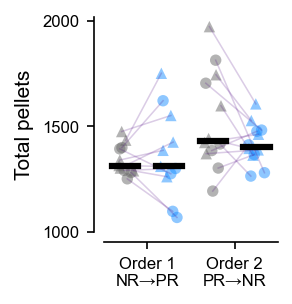

In [ ]:
# Combine male and female data for PR and NR phases within each order
nrpr_order1_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 1})
prnr_order2_data = get_data_fields(mice, ["pr_pellets_per_day", "nr_pellets_per_day"], {"order": 2})

# Sum pellets per day for each order and phase
nrpr_order1_pr_pellets = [sum(pellets) for pellets in nrpr_order1_data[0]]
nrpr_order1_nr_pellets = [sum(pellets) for pellets in nrpr_order1_data[1]]
prnr_order2_pr_pellets = [sum(pellets) for pellets in prnr_order2_data[0]]
prnr_order2_nr_pellets = [sum(pellets) for pellets in prnr_order2_data[1]]

# Prepare data for plotting
data = [nrpr_order1_pr_pellets, nrpr_order1_nr_pellets, prnr_order2_pr_pellets, prnr_order2_nr_pellets]

# Make figure
fig, ax = make_scatter_plot(data, markers_by_order=all_markers)

# Plot settings
ax.set_ylabel("Total pellets", fontsize=10)
ax.set_yticks([1000, 1500, 2000])

# Save the figure
if SAVEFIGS:
    fig.savefig("../plots/Fig2A.pdf", dpi=EXPORT_DPI)


## Figure 5A - Number of Meals

11 items in output dictionary
12 items in output dictionary


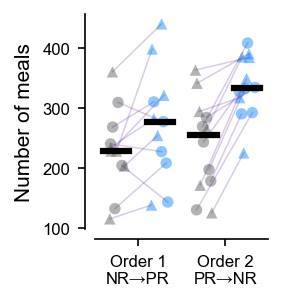

In [ ]:
# Extract combined meal data for PR and NR phases, separated by order
nrpr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 1})
prnr_meals = get_data_fields(mice, ["pr_number_of_meals", "nr_number_of_meals"], {"order": 2})

# Prepare data for plotting
data = [nrpr_meals[0], nrpr_meals[1], prnr_meals[0], prnr_meals[1]]

# Make figure
fig, ax = make_scatter_plot(data, markers_by_order=all_markers)

# Plot settings
ax.set_ylabel("Number of meals", fontsize=10)
ax.set_yticks([100, 200, 300, 400])

if SAVEFIGS:
    fig.savefig("../plots/Fig5A.pdf", dpi=EXPORT_DPI)

## Figure 5C - Meal Size

11 items in output dictionary
12 items in output dictionary


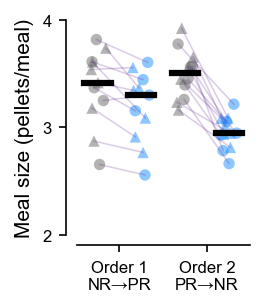

In [ ]:
# Extract combined meal size data for PR and NR phases, separated by order
nrpr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 1})
prnr_size = get_data_fields(mice, ["pr_meal_size", "nr_meal_size"], {"order": 2})

# Prepare data for plotting
data = [nrpr_size[0], nrpr_size[1], prnr_size[0], prnr_size[1]]

# Make figure
fig, ax = make_scatter_plot(data, markers_by_order=all_markers)

# Plot settings
ax.set_ylabel("Meal size (pellets/meal)", fontsize=10)
ax.set_yticks([2, 3, 4])

if SAVEFIGS:
    fig.savefig("../plots/Fig5C.pdf", dpi=EXPORT_DPI)

## Figure 6A - Number of Snacks

11 items in output dictionary
12 items in output dictionary


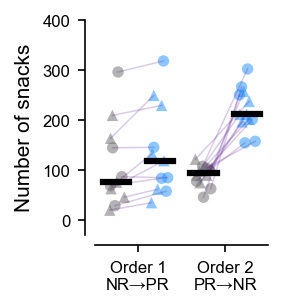

In [ ]:
# Extract combined snack count data for PR and NR phases, separated by order
nrpr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 1})
prnr_snacks = get_data_fields(mice, ["pr_number_of_snacks", "nr_number_of_snacks"], {"order": 2})

# Prepare data for plotting
data = [nrpr_snacks[0], nrpr_snacks[1], prnr_snacks[0], prnr_snacks[1]]

# Make figure
fig, ax = make_scatter_plot(data, markers_by_order=all_markers)

# Plot settings
ax.set_ylabel("Number of snacks", fontsize=10)
ax.set_yticks([0, 100, 200, 300, 400])
ax.set_ylim(-30, 400)

if SAVEFIGS:
    fig.savefig("../plots/Fig6A.pdf", dpi=EXPORT_DPI)


## Figures 7A and 8A - Number of Feasts

6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


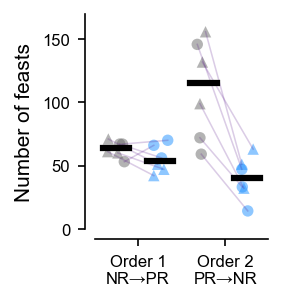

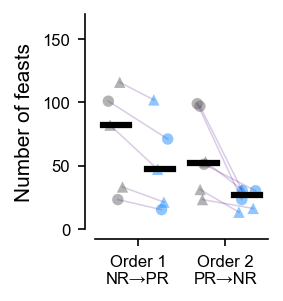

In [ ]:
nrpr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "M"})
prnr_male_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "M"})
nrpr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 1, "sex": "F"})
prnr_female_feast_freq = get_data_fields(mice, ["pr_number_of_mega_meals", "nr_number_of_mega_meals"], {"order": 2, "sex": "F"})

# Prepare lists in the order: [O1-PR, O1-NR, O2-PR, O2-NR]
male_data = [
    np.asarray(nrpr_male_feast_freq[0]), np.asarray(nrpr_male_feast_freq[1]),
    np.asarray(prnr_male_feast_freq[0]), np.asarray(prnr_male_feast_freq[1]),
]
female_data = [
    np.asarray(nrpr_female_feast_freq[0]), np.asarray(nrpr_female_feast_freq[1]),
    np.asarray(prnr_female_feast_freq[0]), np.asarray(prnr_female_feast_freq[1]),
]

# Make figure (male)
fig, ax = make_scatter_plot(male_data, markers_by_order=male_markers)

# Plot settings
ax.set_ylabel("Number of feasts", fontsize=10)
ax.set_yticks([0, 50, 100, 150])
ax.set_ylim(0, 170)

if SAVEFIGS:
    fig.savefig("../plots/Fig7A.pdf", dpi=EXPORT_DPI)
    
# Make figure (female)
fig, ax = make_scatter_plot(female_data, markers_by_order=female_markers)

# Plot settings
ax.set_ylabel("Number of feasts", fontsize=10)
ax.set_yticks([0, 50, 100, 150])
ax.set_ylim(0, 170)

if SAVEFIGS:
    fig.savefig("../plots/Fig8A.pdf", dpi=EXPORT_DPI)

## Figures 7C and 8C - Feast Size

6 items in output dictionary
6 items in output dictionary
5 items in output dictionary
6 items in output dictionary


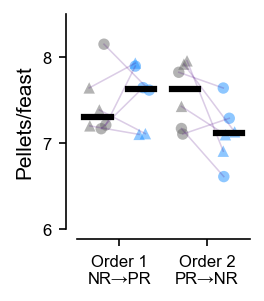

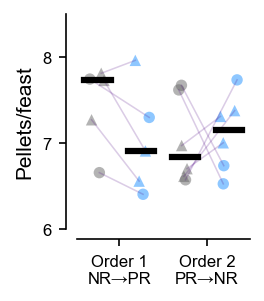

In [ ]:
# Extract Feast size data for PR and NR phases, separated by order and sex
nrpr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "M"})
prnr_male_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "M"})
nrpr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 1, "sex": "F"})
prnr_female_feast_size = get_data_fields(mice, ["pr_mega_meal_size", "nr_mega_meal_size"], {"order": 2, "sex": "F"})

# Prepare lists in the order: [O1-PR, O1-NR, O2-PR, O2-NR]
male_data = [
    np.asarray(nrpr_male_feast_size[0]), np.asarray(nrpr_male_feast_size[1]),
    np.asarray(prnr_male_feast_size[0]), np.asarray(prnr_male_feast_size[1]),
]
female_data = [
    np.asarray(nrpr_female_feast_size[0]), np.asarray(nrpr_female_feast_size[1]),
    np.asarray(prnr_female_feast_size[0]), np.asarray(prnr_female_feast_size[1]),
]

# Make figure (male)
fig, ax = make_scatter_plot(male_data, markers_by_order=male_markers)

# Plot settings
ax.set_ylabel("Pellets/feast", fontsize=10)
ax.set_yticks([6, 7, 8,])
ax.set_ylim(6, 8.5)

if SAVEFIGS:
    fig.savefig("../plots/Fig7C.pdf", dpi=EXPORT_DPI)
    
# Make figure (female)
fig, ax = make_scatter_plot(female_data, markers_by_order=female_markers)

# Plot settings
ax.set_ylabel("Pellets/feast", fontsize=10)
ax.set_yticks([6, 7, 8,])
ax.set_ylim(6, 8.5)

if SAVEFIGS:
    fig.savefig("../plots/Fig8C.pdf", dpi=EXPORT_DPI)

## Figure 9A - Total Feeding Events

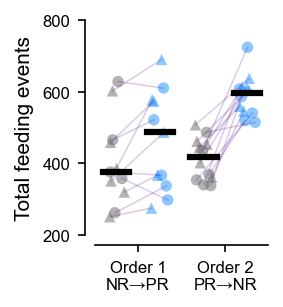

In [ ]:
# Load the dataset
file_path = '../results/scatter_plots/SUM_OF_FEEDING_COMPONENTS/TOTAL_FEEDING_EVENTS.csv'
data = pd.read_csv(file_path)

# Separate data by order
nrpr_order1_data = data[data['Order'] == 1]
prnr_order2_data = data[data['Order'] == 2]

# Extract feeding data for plotting
nrpr_order1_pr = nrpr_order1_data['Total PR Parameters'].values
nrpr_order1_nr = nrpr_order1_data['Total NR Parameters'].values
prnr_order2_pr = prnr_order2_data['Total PR Parameters'].values
prnr_order2_nr = prnr_order2_data['Total NR Parameters'].values

# Prepare data for plotting
feeding_totals = [
    nrpr_order1_pr, nrpr_order1_nr,
    prnr_order2_pr, prnr_order2_nr
]
markers_by_order = {
    "Order 1": [marker_map[sex] for sex in nrpr_order1_data['Sex']],
    "Order 2": [marker_map[sex] for sex in prnr_order2_data['Sex']],
}

# Make figure
fig, ax = make_scatter_plot(feeding_totals, markers_by_order=markers_by_order)

# Plot settings
ax.set_ylabel("Total feeding events", fontsize=10)
ax.set_yticks([200, 400, 600, 800])

if SAVEFIGS:
    fig.savefig("../plots/Fig9A.pdf", dpi=EXPORT_DPI)